# Title: Titanic Survival Prediction using Machine Learning

# Problem Statement
In this project we can predict whether a passenger survived the Titanic disaster or not using Machine learning. The dataset contains information about passengers such as Pclass, Sex, Age, SibSp, Parch, Fare, and Embarked. In this dataset, Survived is the target variable, where 1 means the passenger survived and 0 means the passenger did not survive.

While checking the dataset, i found that some columns contained missing NULL values, especially in Age and Embarked. These missing values were taken care during preprocessing by replacing numerical values with median and categorical values with mode. Some unnecessary columns were also removed to improve the dataset.

After cleaning the data, the remaining features were used as independent variables (X) and Survived was used as the dependent variable (Y). The dataset was then prepared for training machine learning models.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Data Collection / Dataset

In [ ]:
df=pd.read_csv("/content/Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [ ]:
df.shape

(891, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.head(65)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
60,61,0,3,"Sirayanian, Mr. Orsen",male,22.0,0,0,2669,7.2292,NaN,C
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0000,B28,NaN
62,63,0,1,"Harris, Mr. Henry Birkhardt",male,45.0,1,0,36973,83.4750,C83,S
63,64,0,3,"Skoog, Master. Harald",male,4.0,3,2,347088,27.9000,NaN,S


# Data Preprocessing

In [ ]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
med=df["Age"].median()
df["Age"]= df["Age"].fillna(med)
df.head(65)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
60,61,0,3,"Sirayanian, Mr. Orsen",male,22.0,0,0,2669,7.2292,NaN,C
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0000,B28,NaN
62,63,0,1,"Harris, Mr. Henry Birkhardt",male,45.0,1,0,36973,83.4750,C83,S
63,64,0,3,"Skoog, Master. Harald",male,4.0,3,2,347088,27.9000,NaN,S


In [ ]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df=df.drop("Cabin",axis=1)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [ ]:
from sklearn.preprocessing import LabelEncoder

mode=df["Embarked"].mode()[0]
df["Embarked"]= df["Embarked"].fillna(mode)

le=LabelEncoder()
df["Embarked"]=le.fit_transform(df["Embarked"])
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,2


In [ ]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df=df.drop("Name",axis=1)
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,2
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,0
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,2
3,4,1,1,female,35.0,1,0,113803,53.1000,2
4,5,0,3,male,35.0,0,0,373450,8.0500,2


In [ ]:
df=df.drop("Ticket",axis=1)
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,2
1,2,1,1,female,38.0,1,0,71.2833,0
2,3,1,3,female,26.0,0,0,7.9250,2
3,4,1,1,female,35.0,1,0,53.1000,2
4,5,0,3,male,35.0,0,0,8.0500,2


In [ ]:
df=df.drop("PassengerId",axis=1)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,2
1,1,1,female,38.0,1,0,71.2833,0
2,1,3,female,26.0,0,0,7.9250,2
3,1,1,female,35.0,1,0,53.1000,2
4,0,3,male,35.0,0,0,8.0500,2


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["Sex"]=le.fit_transform(df["Sex"])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [ ]:
df['Embarked'].value_counts()

,count
Embarked,
2,646
0,168
1,77


# Exploratory Data Analysis (EDA)

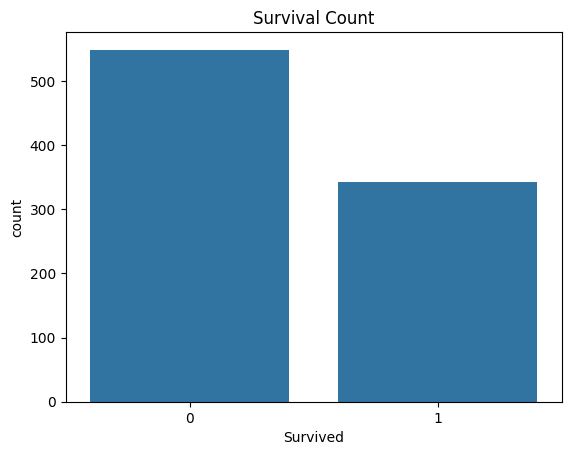

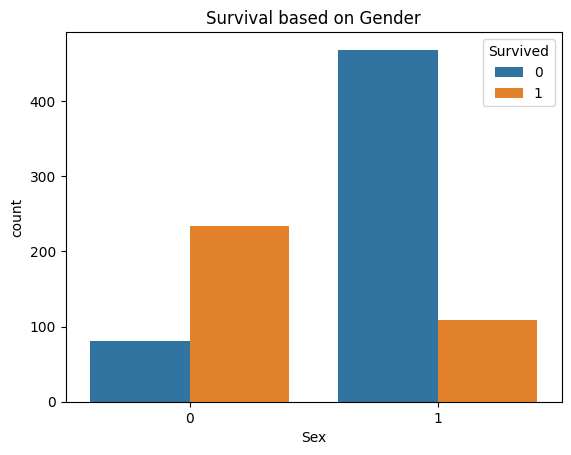

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival based on Gender")
plt.show()

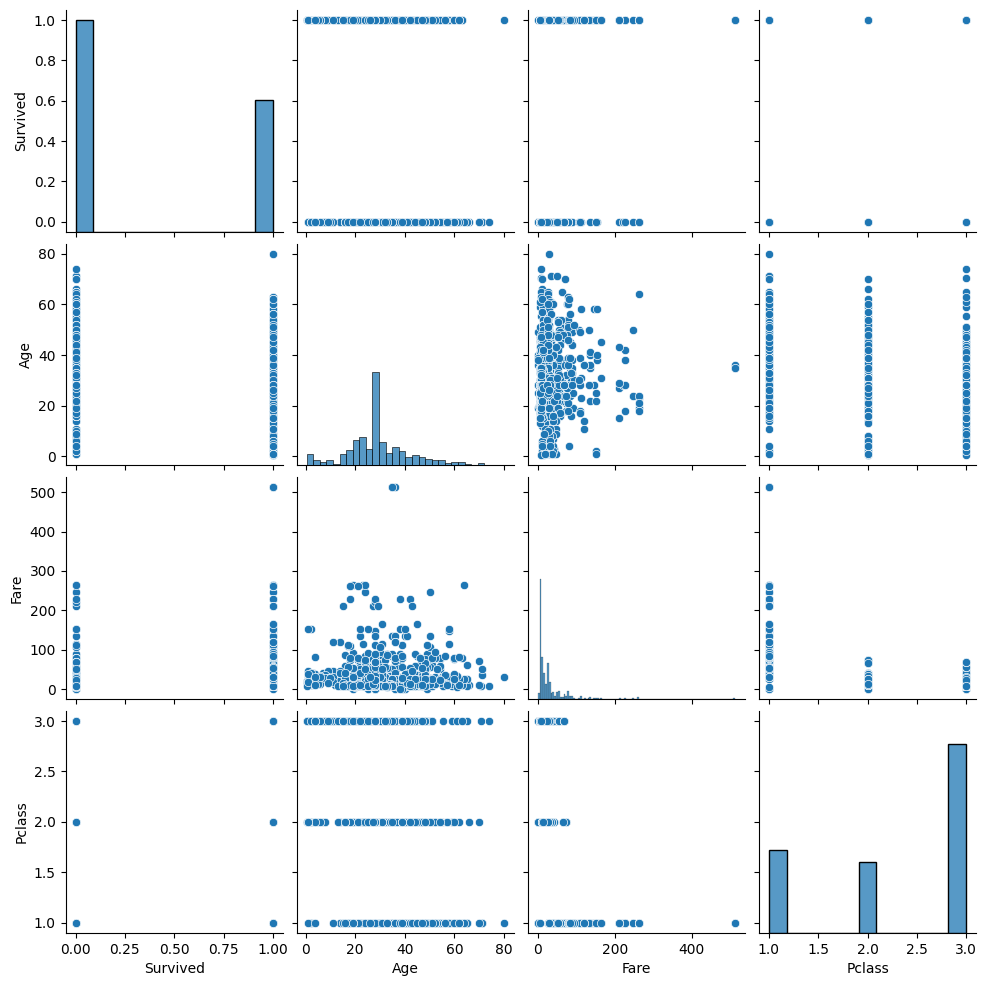

In [ ]:
sns.pairplot(df[["Survived", "Age", "Fare", "Pclass"]])
plt.show()

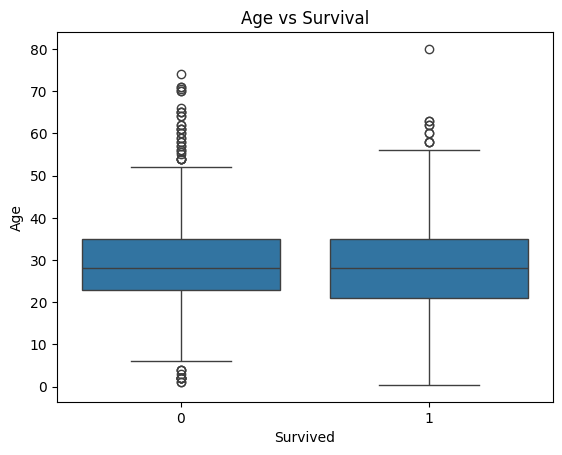

In [ ]:
sns.boxplot(x="Survived", y="Age", data=df)
plt.title("Age vs Survival")
plt.show()

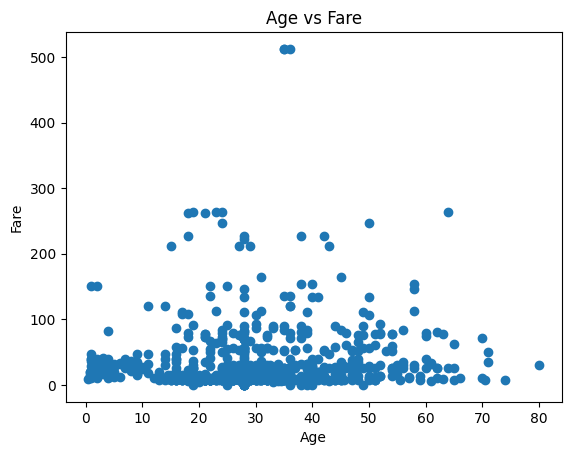

In [ ]:
plt.scatter(df["Age"], df["Fare"])
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Age vs Fare")
plt.show()

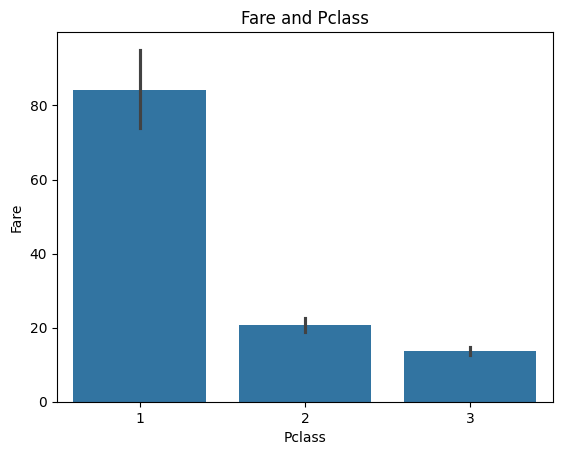

In [ ]:


sns.barplot(x="Pclass", y=("Fare"), data=df)
plt.title("Fare and Pclass")
plt.show()

(array([ 54.,  46., 177., 346., 118.,  70.,  45.,  24.,   9.,   2.]),
 array([ 0.42 ,  8.378, 16.336, 24.294, 32.252, 40.21 , 48.168, 56.126,
        64.084, 72.042, 80.   ]),
 <BarContainer object of 10 artists>)

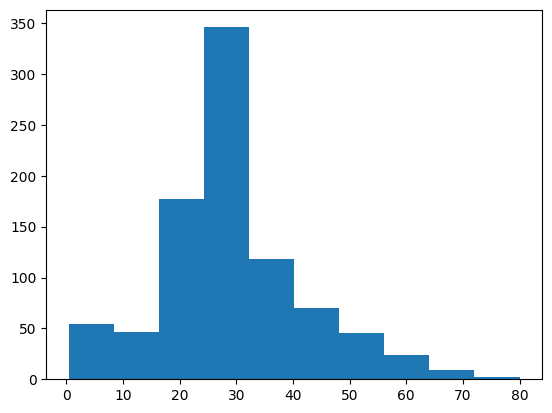

In [ ]:
plt.hist(df['Age'])

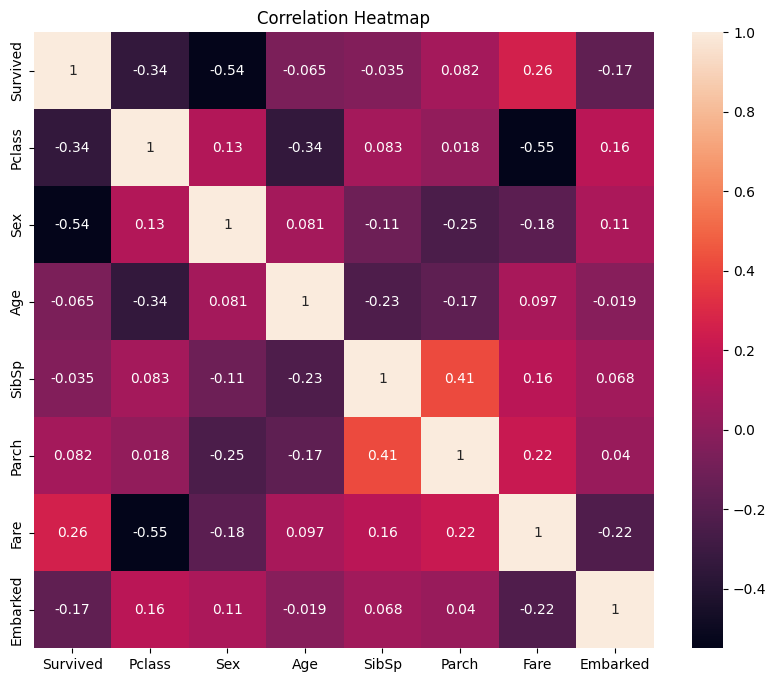

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Feature Selection

In [ ]:
x=df.drop(columns="Survived", axis=1)
y=df["Survived"]

In [ ]:
print(x)

     Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         3    1  22.0      1      0   7.2500         2
1         1    0  38.0      1      0  71.2833         0
2         3    0  26.0      0      0   7.9250         2
3         1    0  35.0      1      0  53.1000         2
4         3    1  35.0      0      0   8.0500         2
..      ...  ...   ...    ...    ...      ...       ...
886       2    1  27.0      0      0  13.0000         2
887       1    0  19.0      0      0  30.0000         2
888       3    0  28.0      1      2  23.4500         2
889       1    1  26.0      0      0  30.0000         0
890       3    1  32.0      0      0   7.7500         1

[891 rows x 7 columns]


In [ ]:
print(y)

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64


# Train-Test-Split

In [ ]:
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2, stratify=y,random_state=2)

In [ ]:
print(x.shape,x_train.shape,x_test.shape)

(891, 7) (712, 7) (179, 7)


# Model Building & Evaluation

In [ ]:
model=LogisticRegression()
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
pred=model.predict(x_test)
from sklearn.metrics import confusion_matrix,accuracy_score

In [ ]:
confusion_matrix(y_test,pred)

array([[92, 18],
       [20, 49]])

In [ ]:
accuracy_score(y_test,pred)

0.7877094972067039

In [ ]:
input_data=(3,0,22,1,0,7.25,2)
ab=np.asarray(input_data)
ba=ab.reshape(1,-1)

prediction=model.predict(ba)
print(prediction)

if prediction[0]==1:
  print("The Passenger Survived")
else:
  print("The Passenger did not Survive")

[1]
The Passenger Survived


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
import warnings
warnings.simplefilter("ignore")

input_data=(3,0,22,1,0,7.25,2)
ab=np.asarray(input_data)
ba=ab.reshape(1,-1)

prediction=model.predict(ba)
print(prediction)

if prediction[0]==1:
  print("The Passenger Survived")
else:
  print("The Passenger did not Survive")

[1]
The Passenger Survived


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=7)
model.fit(x_train,y_train)
pred=model.predict(x_test)
from sklearn.metrics import confusion_matrix,accuracy_score
print(confusion_matrix(y_test,pred))
print(accuracy_score(y_test,pred))

[[91 19]
 [29 40]]
0.7318435754189944


In [ ]:
import warnings
warnings.simplefilter("ignore")

input_data=(3,0,22,1,0,7.25,2)
ab=np.asarray(input_data)
ba=ab.reshape(1,-1)

prediction=model.predict(ba)
print(prediction)

if prediction[0]==1:
  print("The Passenger Survived")
else:
  print("The Passenger did not Survive")

[0]
The Passenger did not Survive


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(x_train,y_train)
pred=model.predict(x_test)
from sklearn.metrics import confusion_matrix,accuracy_score
print(confusion_matrix(y_test,pred))
print(accuracy_score(y_test,pred))

[[89 21]
 [24 45]]
0.7486033519553073


In [ ]:
import warnings
warnings.simplefilter("ignore")

input_data=(3,0,22,1,0,7.25,2)
ab=np.asarray(input_data)
ba=ab.reshape(1,-1)

prediction=model.predict(ba)
print(prediction)

if prediction[0]==1:
  print("The Passenger Survived")
else:
  print("The Passenger did not Survive")

[1]
The Passenger Survived


In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(x_train,y_train)
pred=model.predict(x_test)
from sklearn.metrics import confusion_matrix,accuracy_score
print(confusion_matrix(y_test,pred))
print(accuracy_score(y_test,pred))


[[98 12]
 [17 52]]
0.8379888268156425


In [ ]:
from sklearn.neural_network import MLPClassifier

ann_model = MLPClassifier()
ann_model.fit(x_train, y_train)

ann_pred = ann_model.predict(x_test)

from sklearn.metrics import confusion_matrix, accuracy_score
print(confusion_matrix(y_test, ann_pred))
print(accuracy_score(y_test, ann_pred))

[[91 19]
 [19 50]]
0.7877094972067039


# Model Optimization

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)

model = grid.best_estimator_

Best Parameters: {'max_depth': 5, 'n_estimators': 50}


In [ ]:
model = grid.best_estimator_

In [ ]:
print(model)

RandomForestClassifier(max_depth=5, n_estimators=50)


# Model Validation

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, x_train, y_train, cv=5)
print("Cross Validation Accuracy:", scores.mean())

Cross Validation Accuracy: 0.8117896188318724


# Feature Importance

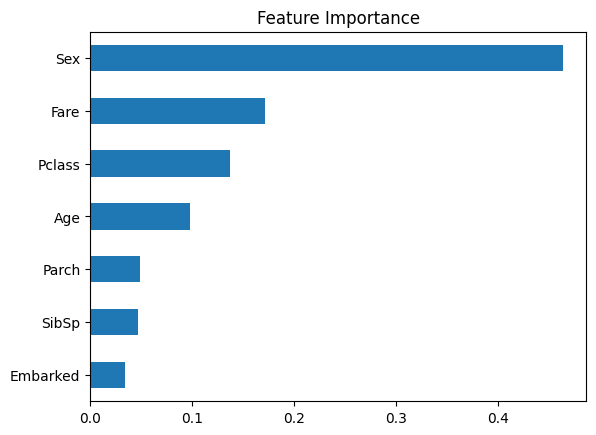

In [ ]:
importance = model.feature_importances_
features = x.columns

import pandas as pd
pd.Series(importance, index=features).sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

# Prediction System

In [ ]:
import warnings
warnings.simplefilter("ignore")

input_data=(3,0,22,1,0,7.25,2)
ab=np.asarray(input_data)
ba=ab.reshape(1,-1)

prediction=model.predict(ba)
print(prediction)

if prediction[0]==1:
  print("The Passenger Survived")
else:
  print("The Passenger did not Survive")

[1]
The Passenger Survived


In [ ]:
from sklearn.svm import SVC
model=SVC(kernel='linear')
model.fit(x_train,y_train)
pred=model.predict(x_test)
from sklearn.metrics import confusion_matrix,accuracy_score
print(confusion_matrix(y_test,pred))
print(accuracy_score(y_test,pred))

[[92 18]
 [22 47]]
0.776536312849162


In [ ]:
import warnings
warnings.simplefilter("ignore")

input_data=(3,0,22,1,0,7.25,2)
ab=np.asarray(input_data)
ba=ab.reshape(1,-1)

prediction=model.predict(ba)
print(prediction)

if prediction[0]==1:
  print("The Passenger Survived")
else:
  print("The Passenger did not Survive")

[1]
The Passenger Survived


# Deployment (Gradio)

In [ ]:
import gradio as gr
import numpy as np

# The model variable is already set to RandomForestClassifier, which achieved the highest accuracy.
# We will use this 'model' for the Gradio interface.

def predict_survival(pclass, sex, age, sibsp, parch, fare, embarked):
    # Map Sex to numerical values (0 for female, 1 for male)
    sex_encoded = 1 if sex == "Male" else 0

    # Map Embarked to numerical values (0 for Cherbourg, 1 for Queenstown, 2 for Southampton)
    embarked_map = {"Cherbourg": 0, "Queenstown": 1, "Southampton": 2}
    if embarked not in embarked_map:
      return "Invalid Input"
    embarked_encoded = embarked_map.get(embarked)

    # Create a numpy array from the input data
    input_data = (pclass, sex_encoded, age, sibsp, parch, fare, embarked_encoded)
    input_as_numpy_array = np.asarray(input_data)

    # Reshape the array for the model
    input_reshaped = input_as_numpy_array.reshape(1, -1)

    # Make prediction
    prediction = model.predict(input_reshaped)

    if prediction[0] == 1:
        return "The Passenger Survived."
    else:
        return "The Passenger did not Survive."

# Define Gradio input components
inputs = [
    gr.Dropdown([1, 2, 3], label="Pclass (Passenger Class)", value=3),
    gr.Radio(["Male", "Female"], label="Sex", value="Male"),
    gr.Slider(minimum=0.42, maximum=80.0, step=1.0, label="Age", value=28.0),
    gr.Slider(minimum=0, maximum=8, step=1, label="SibSp (Siblings/Spouses Aboard)", value=1),
    gr.Slider(minimum=0, maximum=6, step=1, label="Parch (Parents/Children Aboard)", value=0),
    gr.Number(label="Fare", value=7.25),
    gr.Dropdown(["Cherbourg", "Queenstown", "Southampton"], label="Embarked", value="Southampton")
]

# Create Gradio interface
output = gr.Textbox(label="Survival Prediction")

gradio_interface = gr.Interface(
    fn=predict_survival,
    inputs=inputs,
    outputs=output,
    title="Titanic Survival Prediction",
    description="Enter passenger details to predict survival on the Titanic."
)

# Launch the interface
gradio_interface.launch(inline=True, share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://376071002486f7c06d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Conclusion
In this project, i built a Machine learning model to predict whether a passenger survived the Titanic disaster. The dataset was first cleaned by handling missing values and converting categorical variables into numerical form so that Machine learning algorithms could process the data.

The dataset was then divided into training and testing sets using the train_test_split method. Different Machine learning models were applied to the dataset to check their performance. These models included LogisticRegression, KNeighborsClassifier, DecisionTreeClassifier, RandomForestClassifier and also SVC(Support Vector Classifier).

Even the ANN Model was used, but it did not give more or better accuracy than RandomForestClassifier.

After comparing the results of these models, the RandomForestClassifier produced the highest accuracy of about 83%. Therefore, this model is considered the best model for predicting passenger survival in this project.

Hyperparameter tuning and cross-validation were used to improve the model performance. Feature importance shows that Sex, Pclass and Fare are the most important features.

Overall, this project shows how Machine learning can be used to analyze data and make predictions based on available information.